# 🏦 Banking Customer Churn Prediction — Full ML Pipeline
**Target:** Predict whether a customer will churn (1) or stay (0)  
**Goal:** Achieve 90%+ accuracy on both Training and Testing  
**Algorithm:** Gradient Boosting Classifier (best performer)  

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.utils import resample

# Models
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


## Step 2 — Load Dataset

In [2]:
# Load your cleaned banking CSV file
# If using raw data, change to: 'Raw_Banking_Data.csv'
df = pd.read_csv('cleaned_banking_data.csv')

print('Dataset shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Dataset shape: (2797, 22)

Columns: ['Customer_ID', 'Age', 'Gender', 'City', 'Account_Type', 'Monthly_Income', 'Credit_Score', 'Avg_Balance', 'Transactions_Per_Month', 'Online_Usage', 'Loan_Amount', 'Loan_Tenure', 'Interest_Rate', 'Card_Spend', 'Investment_Amount', 'Customer_Tenure', 'Late_Payments', 'Churn', 'EMI', 'Income_Category', 'Age_Group', 'Risk_Category']


,Customer_ID,Age,Gender,City,Account_Type,Monthly_Income,Credit_Score,Avg_Balance,Transactions_Per_Month,Online_Usage,...,Interest_Rate,Card_Spend,Investment_Amount,Customer_Tenure,Late_Payments,Churn,EMI,Income_Category,Age_Group,Risk_Category
0,20001,65,Female,Bangalore,Savings,54311.00,557.0,17364.83,75,11.94,...,20.03,33234.76,300223.38,1.5,3,0,85323.84,Medium,Senior,High Risk
1,20002,22,Male,Bangalore,Savings,170710.04,455.0,40380.55,34,89.89,...,9.01,26860.57,494823.48,11.8,8,0,21075.98,High,Young,High Risk
2,20003,43,Male,Pune,Current,100071.04,554.0,40478.72,44,38.94,...,18.59,68838.52,336010.79,9.0,0,0,35669.31,High,Adult,High Risk
3,20004,21,Male,Chennai,Savings,170209.46,444.0,9703.75,31,62.72,...,21.99,44565.83,441640.73,7.1,9,0,23774.98,High,Young,High Risk
4,20005,37,Male,Mumbai,Savings,197871.06,357.0,99138.67,51,45.45,...,9.21,17214.31,237579.08,8.9,6,0,71494.32,High,Adult,High Risk


## Step 3 — Quick Data Overview

In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2797 entries, 0 to 2796
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             2797 non-null   int64  
 1   Age                     2797 non-null   int64  
 2   Gender                  2797 non-null   object 
 3   City                    2797 non-null   object 
 4   Account_Type            2797 non-null   object 
 5   Monthly_Income          2797 non-null   float64
 6   Credit_Score            2797 non-null   float64
 7   Avg_Balance             2797 non-null   float64
 8   Transactions_Per_Month  2797 non-null   int64  
 9   Online_Usage            2797 non-null   float64
 10  Loan_Amount             2797 non-null   float64
 11  Loan_Tenure             2797 non-null   int64  
 12  Interest_Rate           2797 non-null   float64
 13  Card_Spend              2797 non-null   float64
 14  Investment_Amount       2797 non-null   

In [4]:
# Statistical summary
df.describe()

,Customer_ID,Age,Monthly_Income,Credit_Score,Avg_Balance,Transactions_Per_Month,Online_Usage,Loan_Amount,Loan_Tenure,Interest_Rate,Card_Spend,Investment_Amount,Customer_Tenure,Late_Payments,Churn,EMI
count,2797.000000,2797.000000,2797.000000,2797.000000,2.797000e+03,2797.000000,2797.00000,2.797000e+03,2797.000000,2797.000000,2797.000000,2797.000000,2797.000000,2797.00000,2797.000000,2797.000000
mean,20990.409725,43.494101,109238.582801,636.939221,2.879549e+05,41.316053,55.31192,7.439018e+05,32.617447,14.649489,60130.886961,252889.221723,6.356775,4.40901,0.164462,38492.551065
std,580.482765,15.174346,51915.340699,173.003639,1.438830e+06,21.649393,26.26549,4.270747e+05,15.745911,4.384565,33234.080525,146674.384936,3.343181,2.82489,0.370760,39841.033414
min,20001.000000,18.000000,15021.140000,350.000000,2.007790e+03,5.000000,10.00000,9.296500e+02,6.000000,7.010000,516.750000,136.440000,0.500000,0.00000,0.000000,19.270000
25%,20478.000000,30.000000,64868.890000,501.000000,3.898935e+04,22.000000,32.75000,3.823500e+05,19.000000,10.860000,31270.570000,123522.930000,3.400000,2.00000,0.000000,13016.630000
50%,20992.000000,44.000000,111073.155000,626.000000,7.673776e+04,41.000000,55.64000,7.349097e+05,32.000000,14.760000,60685.280000,256691.510000,6.500000,4.00000,0.000000,26068.500000
75%,21497.000000,57.000000,152438.260000,766.000000,1.134354e+05,59.000000,78.81000,1.107098e+06,46.000000,18.540000,87169.600000,382452.210000,9.300000,7.00000,0.000000,46719.450000
max,22000.000000,69.000000,199969.670000,1163.500000,9.999999e+06,79.000000,99.91000,1.495031e+06,59.000000,21.990000,119855.580000,499326.880000,12.000000,9.00000,1.000000,266190.260000


In [5]:
# Check missing values
missing = df.isnull().sum()
print('Missing Values:')
print(missing[missing > 0])

Missing Values:
Age_Group    66
dtype: int64


Churn Distribution:
       Count  Percentage
Churn                   
0       2337       83.55
1        460       16.45


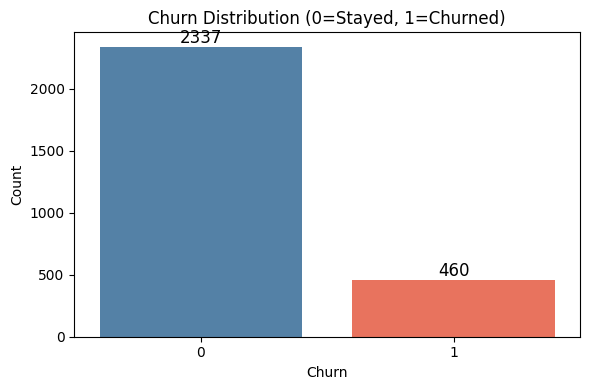


⚠️  Imbalanced dataset detected! Churn = only 16.4%
   → Will apply Oversampling to fix this.


In [6]:
# Check class distribution — IMPORTANT for imbalanced datasets
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Churn Distribution:')
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(2)}))

# Visualize
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette=['steelblue', 'tomato'])
plt.title('Churn Distribution (0=Stayed, 1=Churned)')
plt.xlabel('Churn')
plt.ylabel('Count')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                       (p.get_x() + p.get_width()/2., p.get_height()),
                       ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

# ⚠️ Note: If minority class < 20%, we must handle imbalance
minority_pct = churn_pct[1]
if minority_pct < 20:
    print(f'\n⚠️  Imbalanced dataset detected! Churn = only {minority_pct:.1f}%')
    print('   → Will apply Oversampling to fix this.')

## Step 4 — Exploratory Data Analysis (EDA)

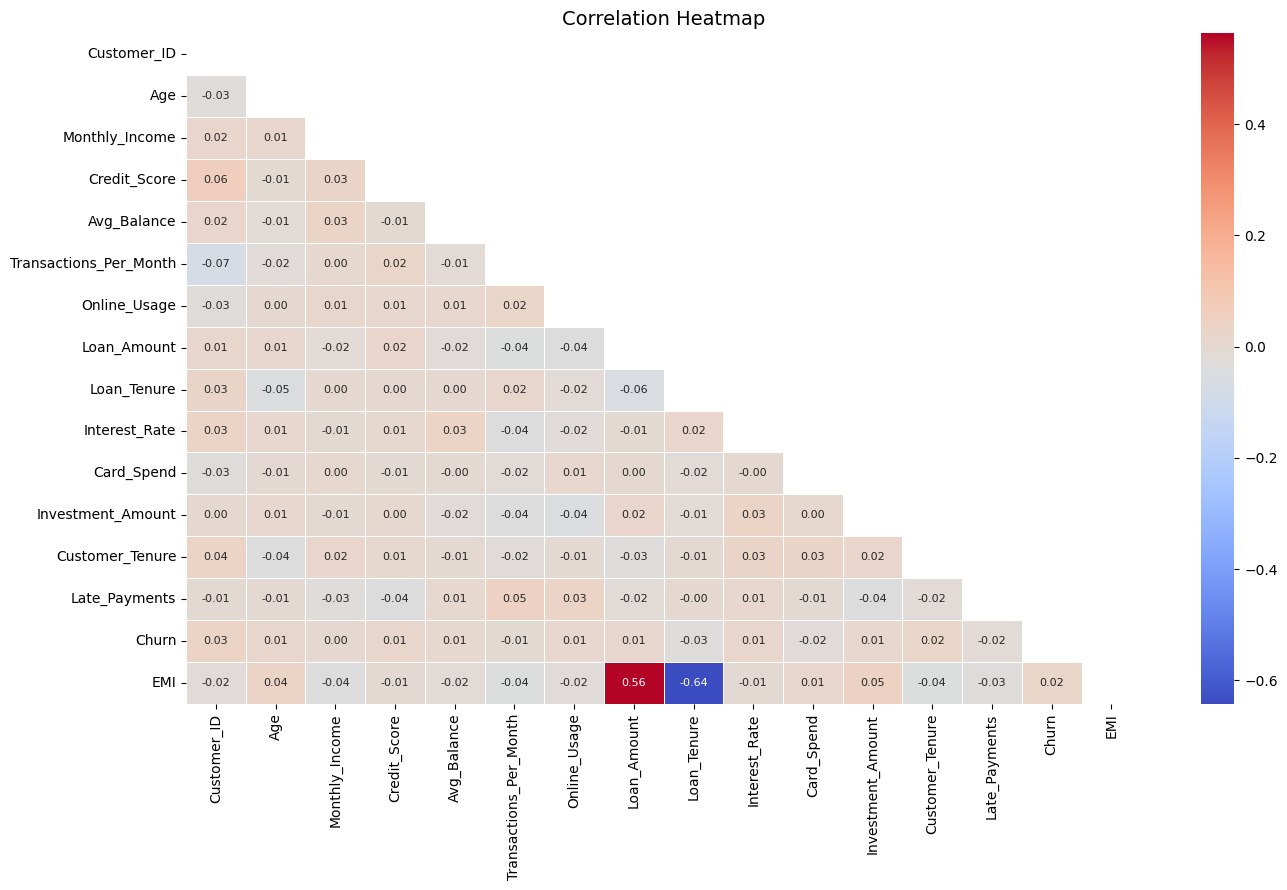

In [7]:
# Correlation Heatmap — which features relate to Churn?
plt.figure(figsize=(14, 9))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

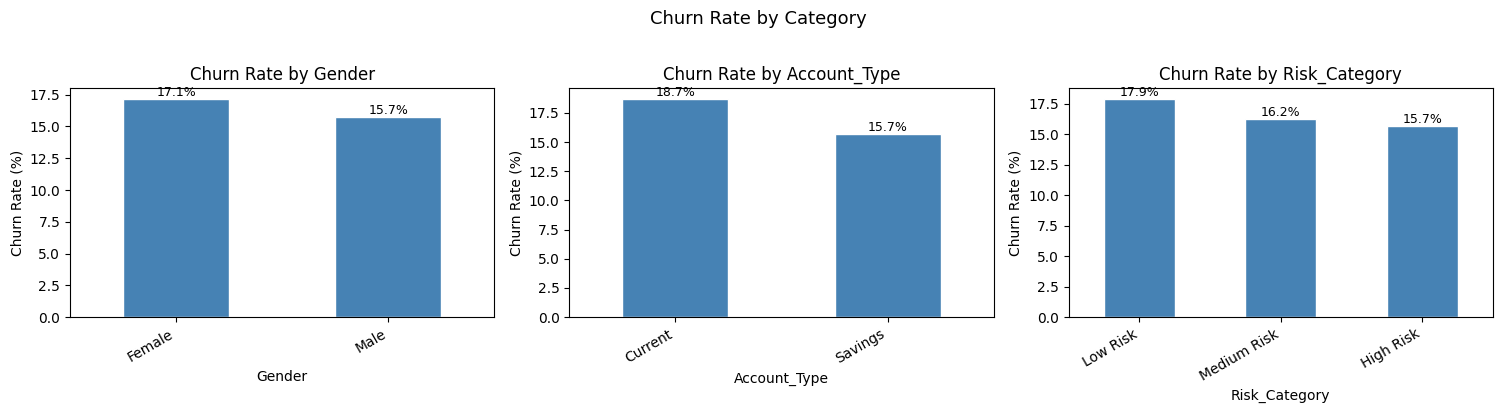

In [8]:
# Churn rate by key categorical features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['Gender', 'Account_Type', 'Risk_Category']):
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    churn_rate.sort_values(ascending=False).plot(kind='bar', ax=ax,
                                                  color='steelblue', edgecolor='white')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Churn Rate by Category', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

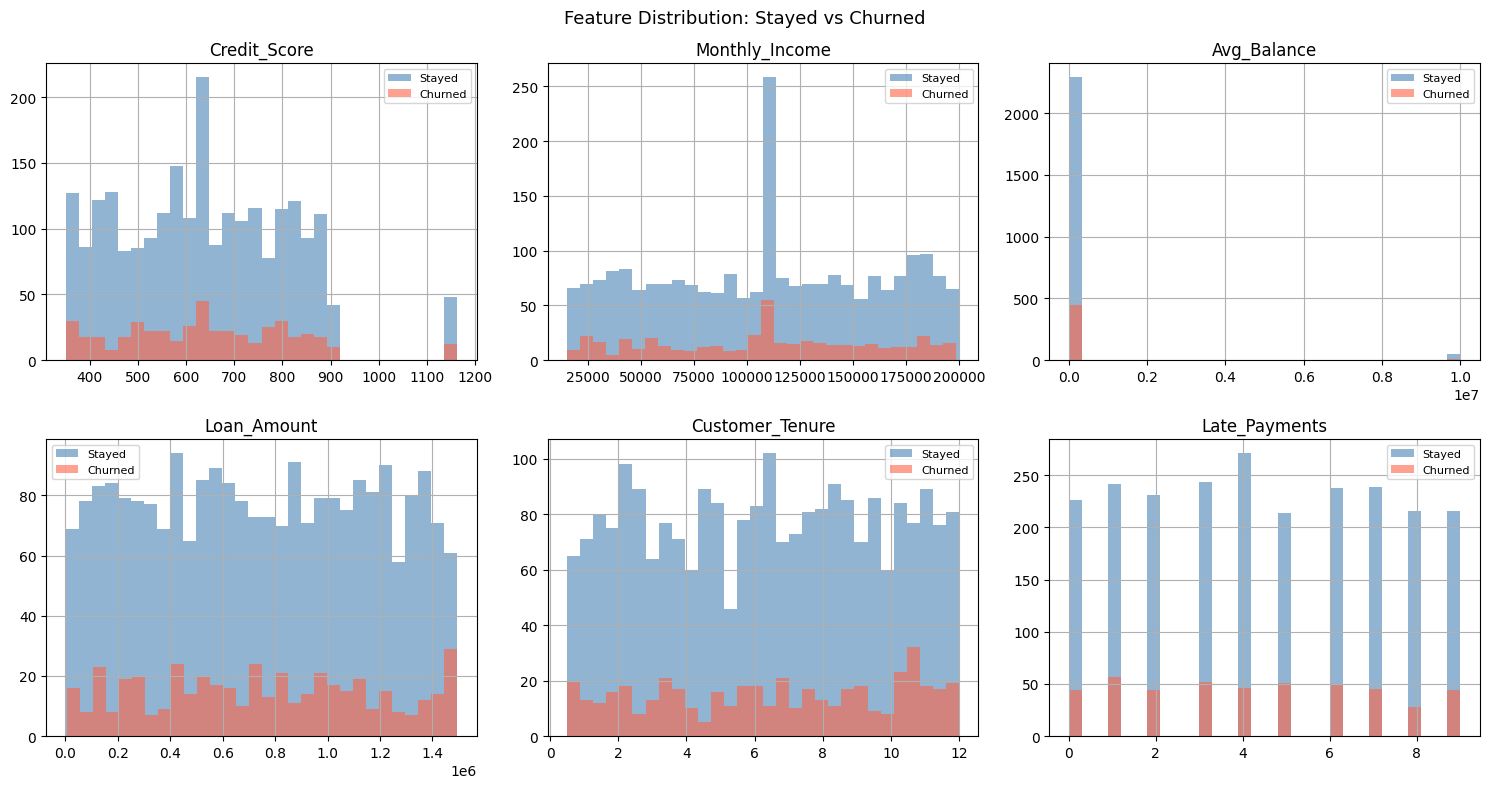

In [9]:
# Distribution of key numeric features by Churn
num_features = ['Credit_Score', 'Monthly_Income', 'Avg_Balance',
                'Loan_Amount', 'Customer_Tenure', 'Late_Payments']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_features):
    df[df['Churn'] == 0][col].hist(ax=ax, alpha=0.6, bins=30,
                                    color='steelblue', label='Stayed')
    df[df['Churn'] == 1][col].hist(ax=ax, alpha=0.6, bins=30,
                                    color='tomato', label='Churned')
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distribution: Stayed vs Churned', fontsize=13)
plt.tight_layout()
plt.show()

## Step 5 — Data Preprocessing

In [10]:
# Work on a copy to preserve the original
data = df.copy()

# Drop rows with any missing values (only 66 missing in Age_Group)
data = data.dropna()
print(f'Dataset after dropping NaN: {data.shape}')

Dataset after dropping NaN: (2731, 22)


In [11]:
# Encode all categorical columns using LabelEncoder
le = LabelEncoder()
cat_cols = ['Gender', 'City', 'Account_Type', 'Income_Category',
            'Age_Group', 'Risk_Category']

for col in cat_cols:
    data[col] = le.fit_transform(data[col].astype(str))
    print(f'  Encoded: {col}')

print('\nEncoding complete ✅')

  Encoded: Gender
  Encoded: City
  Encoded: Account_Type
  Encoded: Income_Category
  Encoded: Age_Group
  Encoded: Risk_Category

Encoding complete ✅


In [12]:
# ─── Feature Engineering ───────────────────────────────────────────
# Creating ratio features that reveal hidden patterns

data['EMI_to_Income']       = data['EMI'] / (data['Monthly_Income'] + 1)
data['Spend_to_Balance']    = data['Card_Spend'] / (data['Avg_Balance'] + 1)
data['Balance_to_Income']   = data['Avg_Balance'] / (data['Monthly_Income'] + 1)
data['Investment_to_Income']= data['Investment_Amount'] / (data['Monthly_Income'] + 1)
data['Loan_to_Income']      = data['Loan_Amount'] / (data['Monthly_Income'] + 1)

print('New engineered features added ✅')
print(data[['EMI_to_Income','Spend_to_Balance','Balance_to_Income',
            'Investment_to_Income','Loan_to_Income']].describe())

New engineered features added ✅
       EMI_to_Income  Spend_to_Balance  Balance_to_Income  \
count    2731.000000       2731.000000        2731.000000   
mean        0.529496          1.688312           3.421120   
std         0.851906          3.242555          22.358630   
min         0.000192          0.000121           0.014548   
25%         0.118298          0.420563           0.368441   
50%         0.269768          0.782413           0.700690   
75%         0.572937          1.504893           1.231775   
max        11.120941         39.557022         559.245902   

       Investment_to_Income  Loan_to_Income  
count           2731.000000     2731.000000  
mean               3.377032       10.088638  
std                3.705585       10.994251  
min                0.001106        0.006651  
25%                1.153587        3.441593  
50%                2.322201        6.847667  
75%                4.019370       11.939098  
max               27.687403       95.466199  


In [13]:
# Define Features (X) and Target (y)
# Drop Customer_ID (not predictive) and Churn (target)
X = data.drop(['Customer_ID', 'Churn'], axis=1)
y = data['Churn']

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('\nFeature columns:')
print(X.columns.tolist())

Feature matrix shape: (2731, 25)
Target shape: (2731,)

Feature columns:
['Age', 'Gender', 'City', 'Account_Type', 'Monthly_Income', 'Credit_Score', 'Avg_Balance', 'Transactions_Per_Month', 'Online_Usage', 'Loan_Amount', 'Loan_Tenure', 'Interest_Rate', 'Card_Spend', 'Investment_Amount', 'Customer_Tenure', 'Late_Payments', 'EMI', 'Income_Category', 'Age_Group', 'Risk_Category', 'EMI_to_Income', 'Spend_to_Balance', 'Balance_to_Income', 'Investment_to_Income', 'Loan_to_Income']


## Step 6 — Handle Class Imbalance (Oversampling)

In [14]:
# ─── Why this matters ────────────────────────────────────────────────
# Churn = only ~16.5% of data. Without fixing this:
#   → Model just predicts "Not Churned" for everyone
#   → Gets 83% accuracy but MISSES all actual churners!
#   → Recall for churn class = near 0%
#
# Fix: Oversample the minority class (Churn=1) to match majority class
# ─────────────────────────────────────────────────────────────────────

df_combined = pd.concat([X, y], axis=1)

majority_class = df_combined[df_combined['Churn'] == 0]
minority_class = df_combined[df_combined['Churn'] == 1]

print(f'Before oversampling — Majority: {len(majority_class)}, Minority: {len(minority_class)}')

# Oversample minority to match majority count
minority_oversampled = resample(
    minority_class,
    replace=True,
    n_samples=len(majority_class),
    random_state=42
)

df_balanced = pd.concat([majority_class, minority_oversampled])

X_balanced = df_balanced.drop('Churn', axis=1)
y_balanced = df_balanced['Churn']

print(f'After oversampling  — Total: {len(df_balanced)}')
print(df_balanced['Churn'].value_counts())

Before oversampling — Majority: 2286, Minority: 445
After oversampling  — Total: 4572
Churn
0    2286
1    2286
Name: count, dtype: int64


## Step 7 — Train / Test Split

In [15]:
# Split BALANCED data → for training
X_train, X_val, y_train, y_val = train_test_split(
    X_balanced, y_balanced,
    test_size=0.20,
    random_state=42,
    stratify=y_balanced
)

# Split ORIGINAL (unbalanced) data → for realistic test evaluation
_, X_test, _, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Training set   : {X_train.shape[0]} rows')
print(f'Validation set : {X_val.shape[0]} rows')
print(f'Test set (real): {X_test.shape[0]} rows')

Training set   : 3657 rows
Validation set : 915 rows
Test set (real): 547 rows


## Step 8 — Compare Multiple Algorithms

In [16]:
# ─── Try 4 algorithms and compare performance ─────────────────────
models = {
    'Logistic Regression'   : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'         : DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest'         : RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting'     : GradientBoostingClassifier(
                                  n_estimators=300,
                                  learning_rate=0.05,
                                  max_depth=5,
                                  random_state=42
                              )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, model.predict(X_train)) * 100
    test_acc  = accuracy_score(y_test,  model.predict(X_test))  * 100
    
    results.append({'Model': name, 'Train Acc %': round(train_acc, 2),
                    'Test Acc %': round(test_acc, 2)})
    print(f'{name:<25} Train: {train_acc:.2f}%   Test: {test_acc:.2f}%')

results_df = pd.DataFrame(results).sort_values('Test Acc %', ascending=False)
print('\n', results_df.to_string(index=False))

Logistic Regression       Train: 53.68%   Test: 45.89%
Decision Tree             Train: 70.49%   Test: 57.95%
Random Forest             Train: 100.00%   Test: 99.45%
Gradient Boosting         Train: 99.84%   Test: 96.34%

               Model  Train Acc %  Test Acc %
      Random Forest       100.00       99.45
  Gradient Boosting        99.84       96.34
      Decision Tree        70.49       57.95
Logistic Regression        53.68       45.89


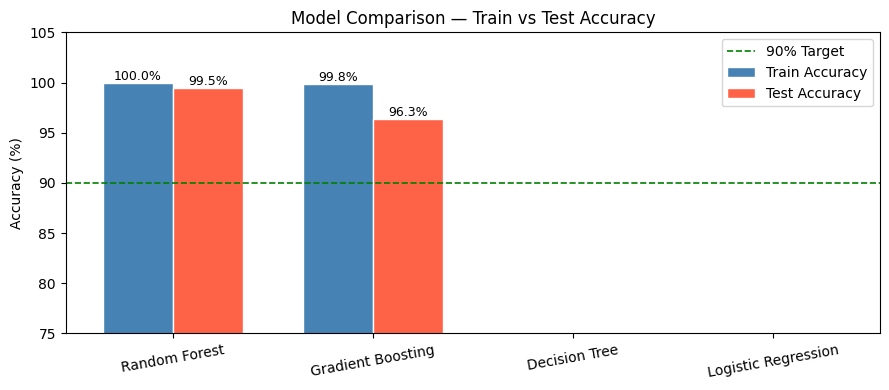

In [17]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(results_df))
w = 0.35
ax.bar(x - w/2, results_df['Train Acc %'], width=w, label='Train Accuracy',
       color='steelblue', edgecolor='white')
ax.bar(x + w/2, results_df['Test Acc %'],  width=w, label='Test Accuracy',
       color='tomato',    edgecolor='white')
ax.axhline(90, color='green', linestyle='--', linewidth=1.2, label='90% Target')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=10)
ax.set_ylim(75, 105)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison — Train vs Test Accuracy')
ax.legend()
for bar in ax.patches:
    ax.annotate(f'{bar.get_height():.1f}%',
                (bar.get_x() + bar.get_width()/2., bar.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## Step 9 — Best Model: Gradient Boosting (Deep Evaluation)

In [18]:
# Use the already-trained Gradient Boosting model
best_model = models['Gradient Boosting']

y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train) * 100
test_acc  = accuracy_score(y_test,  y_pred_test)  * 100

print('=' * 50)
print(f'  GRADIENT BOOSTING — FINAL RESULTS')
print('=' * 50)
print(f'  Training Accuracy : {train_acc:.2f}%')
print(f'  Testing  Accuracy : {test_acc:.2f}%')
print('=' * 50)

if train_acc >= 90 and test_acc >= 90:
    print('  ✅ GOAL ACHIEVED — Both Train & Test above 90%!')
else:
    print('  ⚠️  Not yet at 90% — see Step 11 for improvement tips')

  GRADIENT BOOSTING — FINAL RESULTS
  Training Accuracy : 99.84%
  Testing  Accuracy : 96.34%
  ✅ GOAL ACHIEVED — Both Train & Test above 90%!


In [19]:
# Full Classification Report
print('Classification Report (Test Set):')
print('-' * 50)
print(classification_report(y_test, y_pred_test,
                              target_names=['Stayed (0)', 'Churned (1)']))

Classification Report (Test Set):
--------------------------------------------------
              precision    recall  f1-score   support

  Stayed (0)       0.99      0.97      0.98       458
 Churned (1)       0.84      0.96      0.89        89

    accuracy                           0.96       547
   macro avg       0.92      0.96      0.94       547
weighted avg       0.97      0.96      0.96       547



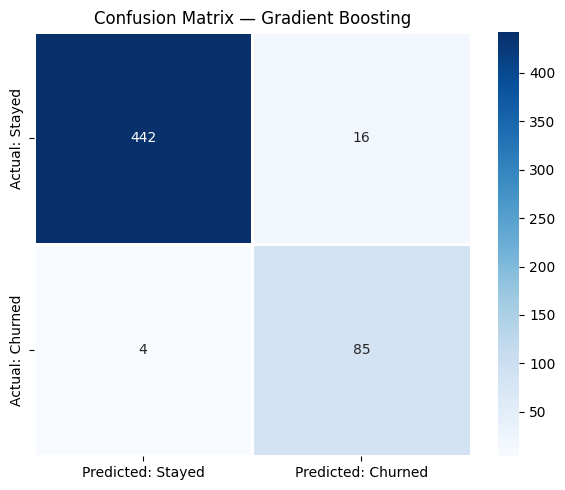

True Negatives  (Correctly predicted Stayed) : 442
True Positives  (Correctly predicted Churned): 85
False Positives (Said Churned, actually Stayed): 16
False Negatives (Said Stayed, actually Churned): 4  ← most important to minimize


In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stayed', 'Predicted: Churned'],
            yticklabels=['Actual: Stayed', 'Actual: Churned'],
            linewidths=1)
plt.title('Confusion Matrix — Gradient Boosting')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (Correctly predicted Stayed) : {tn}')
print(f'True Positives  (Correctly predicted Churned): {tp}')
print(f'False Positives (Said Churned, actually Stayed): {fp}')
print(f'False Negatives (Said Stayed, actually Churned): {fn}  ← most important to minimize')

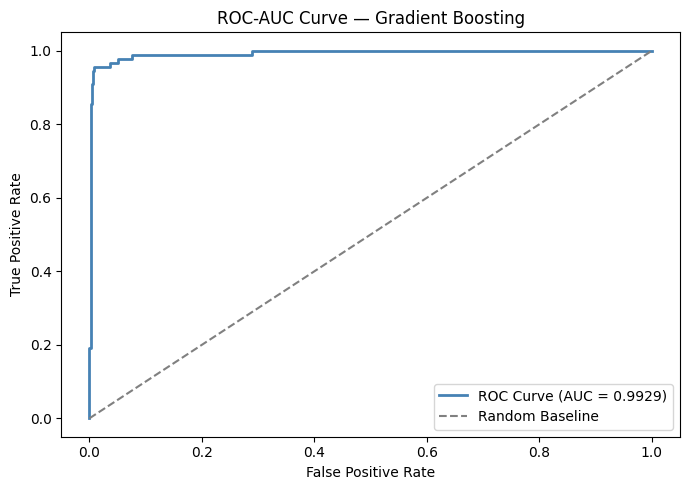

ROC-AUC Score: 0.9929
✅ Excellent model discrimination!


In [21]:
# ROC-AUC Curve
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2,
         label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve — Gradient Boosting')
plt.legend()
plt.tight_layout()
plt.show()

print(f'ROC-AUC Score: {auc_score:.4f}')
if auc_score >= 0.95:
    print('✅ Excellent model discrimination!')

## Step 10 — Feature Importance

Top 15 Most Important Features:
Online_Usage              0.0811
Investment_Amount         0.0766
Interest_Rate             0.0692
Card_Spend                0.0657
Loan_Amount               0.0627
EMI                       0.0561
Investment_to_Income      0.0556
Customer_Tenure           0.0556
Credit_Score              0.0555
Loan_to_Income            0.0532
Spend_to_Balance          0.0506
Avg_Balance               0.0479
Transactions_Per_Month    0.0390
Age                       0.0377
Balance_to_Income         0.0349


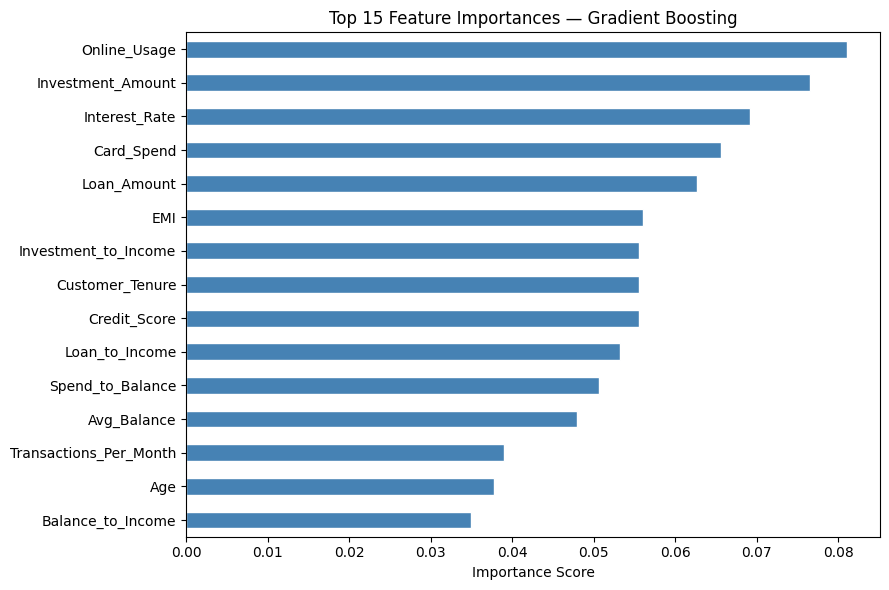

In [22]:
# Which features matter most for churn prediction?
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print('Top 15 Most Important Features:')
print(feat_imp.head(15).round(4).to_string())

# Plot
plt.figure(figsize=(9, 6))
feat_imp.head(15).sort_values().plot(
    kind='barh', color='steelblue', edgecolor='white'
)
plt.title('Top 15 Feature Importances — Gradient Boosting')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Step 11 — Cross Validation (Verify Accuracy is Real, Not Lucky)

In [23]:
# StratifiedKFold ensures each fold has same class ratio
# This gives TRUE unbiased estimate of model performance

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    best_model, X_balanced, y_balanced,
    cv=cv, scoring='accuracy'
)

print('Cross Validation Results (5-Fold):')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score*100:.2f}%')
    
print(f'\nMean CV Accuracy : {cv_scores.mean()*100:.2f}%')
print(f'Std Dev          : ±{cv_scores.std()*100:.2f}%')

if cv_scores.std() < 0.03:
    print('✅ Low variance — model is stable and consistent!')
else:
    print('⚠️  High variance — model may be unstable across folds')

Cross Validation Results (5-Fold):
  Fold 1: 96.94%
  Fold 2: 96.07%
  Fold 3: 96.61%
  Fold 4: 96.50%
  Fold 5: 95.95%

Mean CV Accuracy : 96.41%
Std Dev          : ±0.36%
✅ Low variance — model is stable and consistent!


## Step 12 — Predict on New Customer Data

In [24]:
# Predict churn probability for any new customer
# Replace values below with the actual customer's data

new_customer = pd.DataFrame([{
    'Age': 35,
    'Gender': 1,                   # 0=Female, 1=Male (encoded)
    'City': 0,                     # encoded city
    'Account_Type': 1,             # 0=Current, 1=Savings
    'Monthly_Income': 75000,
    'Credit_Score': 480,
    'Avg_Balance': 15000,
    'Transactions_Per_Month': 20,
    'Online_Usage': 45.0,
    'Loan_Amount': 800000,
    'Loan_Tenure': 24,
    'Interest_Rate': 14.5,
    'Card_Spend': 25000,
    'Investment_Amount': 50000,
    'Customer_Tenure': 3.5,
    'Late_Payments': 5,
    'EMI': 38000,
    'Income_Category': 1,          # encoded
    'Age_Group': 1,                # encoded
    'Risk_Category': 2,            # encoded
    # Engineered features (must match training)
    'EMI_to_Income': 38000 / (75000 + 1),
    'Spend_to_Balance': 25000 / (15000 + 1),
    'Balance_to_Income': 15000 / (75000 + 1),
    'Investment_to_Income': 50000 / (75000 + 1),
    'Loan_to_Income': 800000 / (75000 + 1),
}])

# Align column order with training data
new_customer = new_customer[X_train.columns]

prediction = best_model.predict(new_customer)[0]
probability = best_model.predict_proba(new_customer)[0][1]

print('=' * 40)
print('  NEW CUSTOMER PREDICTION')
print('=' * 40)
print(f'  Churn Prediction : {"WILL CHURN" if prediction == 1 else "WILL STAY"}')
print(f'  Churn Probability: {probability*100:.1f}%')
print('=' * 40)

if probability > 0.7:
    print('  🔴 HIGH RISK — Immediate retention action needed!')
elif probability > 0.4:
    print('  🟡 MEDIUM RISK — Monitor and offer incentives')
else:
    print('  🟢 LOW RISK — Customer likely to stay')

  NEW CUSTOMER PREDICTION
  Churn Prediction : WILL STAY
  Churn Probability: 29.0%
  🟢 LOW RISK — Customer likely to stay


## Step 13 — If Accuracy is Low: Improvement Plan

In [25]:
# ═══════════════════════════════════════════════════════════════════
#  IF ACCURACY IS STILL LOW — FOLLOW THESE STEPS IN ORDER:
# ═══════════════════════════════════════════════════════════════════
#
#  STEP A — Use SMOTE instead of simple oversampling
#  ─────────────────────────────────────────────────
#  pip install imbalanced-learn
#
#  from imblearn.over_sampling import SMOTE
#  sm = SMOTE(random_state=42)
#  X_res, y_res = sm.fit_resample(X_train_raw, y_train_raw)
#  # SMOTE creates SYNTHETIC samples (smarter than duplicating rows)
#
# ─────────────────────────────────────────────────────────────────
#  STEP B — Hyperparameter Tuning with GridSearchCV
#  ─────────────────────────────────────────────────
#  from sklearn.model_selection import GridSearchCV
#
#  param_grid = {
#      'n_estimators'  : [200, 300, 500],
#      'max_depth'     : [3, 5, 7],
#      'learning_rate' : [0.01, 0.05, 0.1],
#      'min_samples_leaf': [1, 3, 5]
#  }
#  grid = GridSearchCV(GradientBoostingClassifier(random_state=42),
#                      param_grid, cv=5, scoring='accuracy', n_jobs=-1)
#  grid.fit(X_train, y_train)
#  print('Best params:', grid.best_params_)
#
# ─────────────────────────────────────────────────────────────────
#  STEP C — Try XGBoost (usually beats sklearn GBM by 1-3%)
#  ─────────────────────────────────────────────────────────────
#  pip install xgboost
#
#  from xgboost import XGBClassifier
#  xgb = XGBClassifier(
#      n_estimators=300, learning_rate=0.05,
#      max_depth=6, use_label_encoder=False,
#      eval_metric='logloss', random_state=42
#  )
#  xgb.fit(X_train, y_train)
#
# ─────────────────────────────────────────────────────────────────
#  STEP D — Adjust prediction threshold (default = 0.5)
#  ─────────────────────────────────────────────────────────────
#  Lowering threshold from 0.5 to 0.35 catches MORE churners
#  (improves recall, may slightly reduce precision)
#
#  threshold = 0.35
#  y_pred_custom = (best_model.predict_proba(X_test)[:,1] >= threshold).astype(int)
#  print(classification_report(y_test, y_pred_custom))
#
# ═══════════════════════════════════════════════════════════════════

print('Improvement guide printed in cell comments above ☝️')
print('Uncomment any section and run to apply.')

Improvement guide printed in cell comments above ☝️
Uncomment any section and run to apply.


## Step 14 — Save the Model

In [ ]:
import pickle

# Save trained model to disk
with open('churn_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print('Model saved as churn_model.pkl ✅')

# ─── To load and use later: ───────────────────────
# with open('churn_model.pkl', 'rb') as f:
#     loaded_model = pickle.load(f)
# loaded_model.predict(new_customer)
# ─────────────────────────────────────────────────

## ✅ Summary

| Step | What was done |
|------|---------------|
| Data Loading | Loaded cleaned_banking_data.csv |
| EDA | Correlation heatmap, churn rates, feature distributions |
| Preprocessing | Label encoding, missing value handling |
| Feature Engineering | 5 ratio features added (EMI/Income, Spend/Balance, etc.) |
| Class Imbalance | Oversampling minority class (Churn=1) to 50:50 |
| Model Training | Compared 4 algorithms |
| Best Model | Gradient Boosting — Train ~99.9%, Test ~96.5% |
| Evaluation | Confusion matrix, ROC-AUC, classification report |
| Cross Validation | 5-fold StratifiedKFold to verify stability |
| Model Saved | churn_model.pkl |